In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().clear_cache()
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner
from ipywidgets import *
import glob
from binning_funcs import bindown_single, bindown_multiple, make_next_level_points, create_point

Numba not installed, using numpy instead


In [18]:
def planet_spectra(wavelength, temperature):

    h = 6.62607015e-34
    c = 299792458
    k = 1.380649e-23

    wl_m = wavelength * 1e-6

    # planet Planck
    Bp = (2*h*c**2) / (wl_m**5 * (np.exp(h*c/(wl_m*k*temperature)) - 1))

    # star Planck (same spectral variable)
    Bs = (2*h*c**2) / (wl_m**5 * (np.exp(h*c/(wl_m*k*star_temp)) - 1))

    r_ratio = ((radius_jup * astropy.constants.R_jup.value)**2) / ((star_rad * astropy.constants.R_sun.value)**2)

    return r_ratio * Bp / Bs

In [2]:
h2o_xsec = OpacityCache()['H2O']
ch4_xsec = OpacityCache()['CH4']
co2_xsec = OpacityCache()['CO2']
co_xsec = OpacityCache()['CO']
nh3_xsec = OpacityCache()['NH3']
o2_xsec = OpacityCache()['O2']
so2_xsec = OpacityCache()['SO2']

In [3]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_transit = [n * 3600 for n in planet_transit] #hours to seconds
T_transit_hours = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours
planet_impact = [0.181, -0.01, 0.717, 0.34, 0.53, 0.14, 0.39, 0.489] #to be fixed according to archive data
planet_eccentricity = [0.05, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0] #to be fixed according to archive data
planet_pericentre_long = [0.0, 90.0, 0.0, 0.0, 228.5, 0.0, 0.0, 90.0] #w, to be fixed according to archive data

star_temperature = [5261.0,4570.0,3381.0,4850.0,4440.0,5342.0,4884.0,4914.0] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr
star_distance = [47.28, 61.87, 18.22, 32.6, 47.39, 85.8, 55.01, 42.58] #pc, to be fixed

In [4]:
#load csv file to display the data in a table
nightside = pd.read_csv('combined_nightside_results.csv', index_col=0)
display(nightside)

,Planet,Surface Pressure [bar],Atmospheric Components,Hydrogen Inventory [H oceans],Redox State,Integration Time (hours),Number of observations,Observations with bb fit,Mean Temperature,Median Temperature,1-sigma Lower,1-sigma Upper
0,HD3167,10.902882,"SO2, H2O",H10,IW4,345.60,15,18.0,684.793264,899.046517,4.260118,1078.279651
1,HD3167,301.889080,"CO2, N2",H20,IW4,299.52,13,15.0,681.030145,879.790166,22.643581,1080.161661
2,K2141,169.221367,"SO2, H2O",H20,IW4,53.76,8,8.0,832.795583,1075.447271,9.345867,1330.462023
3,K2141,16.028394,"SO2, S2",H30,IW2,53.76,8,8.0,875.997260,1083.199393,410.973486,1343.706663
4,LHS1478,317.212366,"H2O, S2",H05,IW0,468000.00,10000,9850.0,232.036301,314.986889,3.034050,347.804389
5,LHS1478,2693.216197,"CO2, H2O",H05,IW4,468000.00,10000,9850.0,234.972027,317.958710,11.123128,349.009930
6,TOI1416,4.994660,"H2, H2O",H10,IW0,720.00,30,35.0,604.242009,810.967962,0.000000,998.715337
7,TOI1416,55.970885,"CO2, SO2",H10,IW4,1176.00,49,53.0,572.883813,766.109011,0.000000,938.521682
8,TOI1416,437.019741,"CO, N2",H20,IW0,840.00,35,37.0,596.799536,796.349503,0.000000,986.541918
9,TOI1807,153.474293,"CO, N2",H10,IW0,277.20,21,21.0,666.128679,910.418318,0.000000,1126.003234


In [108]:
# ============================================================
# PARAMETERS — edit these before running the cells below
# ============================================================

planet_name = "HD3167"         # one of: HD3167, K2141, LHS1478, TOI431, TOI500, TOI561, TOI1416, TOI1807
sim_name    = "H10_IW4_00001"  # simulation sub-folder inside PLANETS/<planet_name>/
N           = 16              # number of observations (noise scaled as yerr = noise/sqrt(N))
binning     = True             # True: plot binned points; False: plot full Ariel grid

ariel  = pd.read_csv(f'ARIEL/arielrad_{planet_name}/tier2.csv', skiprows=6)
wl     = np.array(ariel['Wavelength [um]'])
wb     = np.array(ariel['Bandwidth [um]'])
noise  = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6
yerr   = noise / np.sqrt(N)

In [91]:
# Ariel channel reference — run after the simulation cell to pick bin_indices
print(f"{'idx':>4}  {'wl (µm)':>10}  {'bw (µm)':>10}")
print("-" * 30)
for i, (w, b) in enumerate(zip(wl, wb)):
    print(f"  {i:2d}    {w:10.4f}    {b:10.4f}")


 idx     wl (µm)     bw (µm)
------------------------------
   0        0.5500        0.1000
   1        0.7000        0.2000
   2        0.9500        0.3000
   3        1.1564        0.1128
   4        1.2749        0.1243
   5        1.4056        0.1370
   6        1.5497        0.1511
   7        1.7085        0.1666
   8        1.8836        0.1837
   9        1.9696        0.0392
  10        2.0092        0.0400
  11        2.0496        0.0408
  12        2.0908        0.0416
  13        2.1328        0.0424
  14        2.1757        0.0433
  15        2.2194        0.0442
  16        2.2640        0.0451
  17        2.3095        0.0460
  18        2.3559        0.0469
  19        2.4033        0.0478
  20        2.4516        0.0488
  21        2.5009        0.0498
  22        2.5511        0.0508
  23        2.6024        0.0518
  24        2.6547        0.0528
  25        2.7081        0.0539
  26        2.7625        0.0550
  27        2.8180        0.0561
  28        2.87

In [92]:

# Pairs of Ariel channel indices to combine at level 1.
# Run the reference cell (after the simulation cell) to see index → wavelength mapping.

bin_indices = [(0,1), (2,3), (5,6), (8,9),(10,11), (12,13), (14,15), (16,17), (18,19), (20,21), (22,23),(24,25),(26,27),(28,29),(30,31),(32,33),(34,35),(36,37),(38,39),(40,41),(42,43),(44,45),(46,47),(48,49),(50,51)]

%matplotlib widget

fig = figure(figsize=(8, 4), dpi=100)
frame = fig.add_subplot(1, 1, 1)

wavenumber = h2o_xsec.wavenumberGrid
frame.set_xlim(0.3, 8) #cover Ariel wavelength range
frame.set_xlabel("Wavelength (microns)")
frame.set_ylabel("Opacity (cm^2/molecule)")

xsec, = frame.plot(1e4/wavenumber, h2o_xsec.opacity(1500, 1.0*1e5)) #micron, cm^2/molecule | Kelvin, Pa

def update_cross(temperature=1500.0, pressure_bar=1.0):
    pressure_pa = pressure_bar * 1e5  # convert bar to Pa
    xsec.set_ydata(h2o_xsec.opacity(temperature, pressure_pa))
    frame.relim()
    frame.autoscale_view()
    fig.canvas.draw()

interact(update_cross, temperature=(300.0, 4000.0, 50), pressure_bar=(0.001, 3000.0, 1));

In [93]:
# Map molecule names to loaded xsec objects (only those with available cross-section data)
mol_to_xsec = {
    'H2O':  h2o_xsec,
    'CH4':  ch4_xsec,
    'CO2':  co2_xsec,
    'CO':   co_xsec,
    'NH3':  nh3_xsec,
    'O2':   o2_xsec,
    'SO2':  so2_xsec,
}

wavenumber_grid = h2o_xsec.wavenumberGrid
wavelength_um = 1e4 / wavenumber_grid  # microns

MOL_COLORS = {
    'H2O': 'tab:blue',
    'CO2': 'tab:orange',
    'O2':  'tab:green',
    'SO2': 'gray',
    'CO':  'tab:pink',
    'CH4': 'tab:red',
    'NH3': 'tab:purple',
}


In [109]:
tp_file = f'PLANETS/{planet_name}/{sim_name}_TP.csv'

idx = planet_names.index(planet_name)
mass_jup   = planet_masses[idx] / 317.8
a          = planet_distances[idx]
radius_jup = planet_radius[idx] * (astropy.constants.R_earth.value / astropy.constants.R_jup.value)

pl = Planet(planet_mass=mass_jup, planet_radius=radius_jup, planet_sma=a,
            planet_distance=star_distance[idx],
            impact_param=planet_impact[idx],
            orbital_period=planet_period[idx],
            transit_time=planet_transit[idx])

st = PhoenixStar(temperature=star_temperature[idx], radius=star_radius[idx],
                 metallicity=star_metallicity[idx], distance=star_distance[idx],
                 phoenix_path='Phoenix/')

# --- Read TP profile ---
tp_data         = pd.read_csv(tp_file)
pressure_pa     = tp_data['Pressure (Pa)'].values
temp_substellar = tp_data['Substellar Temperature (K)'].values

surf_p_pa = pressure_pa[0]
top_pa    = pressure_pa[-1]
surf_t    = temp_substellar[0]

p1 = SimplePressureProfile(nlayers=100, atm_min_pressure=np.min(top_pa), atm_max_pressure=np.max(surf_p_pa))
p1.compute_pressure_profile()

# Conditions at 10^-2 bar (= 1000 Pa)
target_p_pa = 1e-2 * 1e5
idx_mid     = np.argmin(np.abs(pressure_pa - target_p_pa))
mid_t       = temp_substellar[idx_mid]

tp1 = TemperatureFile(f'PLANETS/{planet_name}/{sim_name}_TP.csv', skiprows=1,
                      temp_col=2, press_col=0,
                      temp_units='K', press_units='Pa',
                      delimiter=',')

simulation_folder = f"PLANETS/{planet_name}/{sim_name}"
atm_file = next(os.path.join(simulation_folder, f)
                for f in os.listdir(simulation_folder) if f.endswith("atm.nc"))

ds = xr.open_dataset(atm_file)

gases = [m.decode().strip() for m in ds["gases"].values]
vmr   = np.array(ds['x_gas'])

pressure = np.array(ds['p'])
radius   = float(ds['planet_radius']) / astropy.constants.R_jup.value

H2O_x  = float(vmr[:, gases.index('H2O')][0])
CO2_x  = float(vmr[:, gases.index('CO2')][0])
CH4_x  = float(vmr[:, gases.index('CH4')][0])
CO_x   = float(vmr[:, gases.index('CO')][0])
NH3_x  = float(vmr[:, gases.index('NH3')][0])
N2_x   = float(vmr[:, gases.index('N2')][0])
SO2_x  = float(vmr[:, gases.index('SO2')][0])
S2_x   = float(vmr[:, gases.index('S2')][0])
O2_x   = float(vmr[:, gases.index('O2')][0])
H2_x   = float(vmr[:, gases.index('H2')][0])
H2S_x  = float(vmr[:, gases.index('H2S')][0])

total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
if total_vmr > 1:
    H2O_x /= total_vmr; CO2_x /= total_vmr; CH4_x /= total_vmr
    CO_x  /= total_vmr; NH3_x /= total_vmr; N2_x  /= total_vmr
    SO2_x /= total_vmr; S2_x  /= total_vmr; O2_x  /= total_vmr
    H2_x  /= total_vmr; H2S_x /= total_vmr

chemistry = TaurexChemistry(fill_gases=["N2"])
(chemistry
 .addGas(ConstantGas(molecule_name="NH3",  mix_ratio=NH3_x))
 .addGas(ConstantGas(molecule_name="CO2",  mix_ratio=CO2_x))
 .addGas(ConstantGas(molecule_name="H2O",  mix_ratio=H2O_x))
 .addGas(ConstantGas(molecule_name="CH4",  mix_ratio=CH4_x))
 .addGas(ConstantGas(molecule_name="CO",   mix_ratio=CO_x))
 .addGas(ConstantGas(molecule_name="SO2",  mix_ratio=SO2_x))
 .addGas(ConstantGas(molecule_name="S2",   mix_ratio=S2_x))
 .addGas(ConstantGas(molecule_name="O2",   mix_ratio=O2_x))
 .addGas(ConstantGas(molecule_name="H2",   mix_ratio=H2_x))
 .addGas(ConstantGas(molecule_name="H2S",  mix_ratio=H2S_x)))

em_dayside = EmissionModel(
    planet=pl, temperature_profile=tp1,
    chemistry=chemistry, pressure_profile=p1, star=st)
em_dayside.add_contribution(AbsorptionContribution())
em_dayside.add_contribution(CIAContribution(cia_pairs=[
    'CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2',
    'N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
em_dayside.add_contribution(RayleighContribution())
em_dayside.build()

wngrid_t, fpfs_t, tau_t, _ = em_dayside.model()
wlgrid_t = 10000 / wngrid_t[::-1]
fpfs_t   = fpfs_t[::-1]

fb = FluxBinner(wl, wb)
output_t = fb.bindown(wlgrid_t, fpfs_t)
wl_ariel, flux_ariel, *_ = output_t


KeyboardInterrupt: 

In [9]:
mol_contribs = em_dayside.model_full_contrib()

In [10]:
nh3_absorption = mol_contribs[1]['Absorption'][0][1]
co2_absorption = mol_contribs[1]['Absorption'][1][1]
h2o_absorption = mol_contribs[1]['Absorption'][2][1]
ch4_absorption = mol_contribs[1]['Absorption'][3][1]
co_absorption  = mol_contribs[1]['Absorption'][4][1]
so2_absorption = mol_contribs[1]['Absorption'][5][1]
o2_absorption  = mol_contribs[1]['Absorption'][6][1]

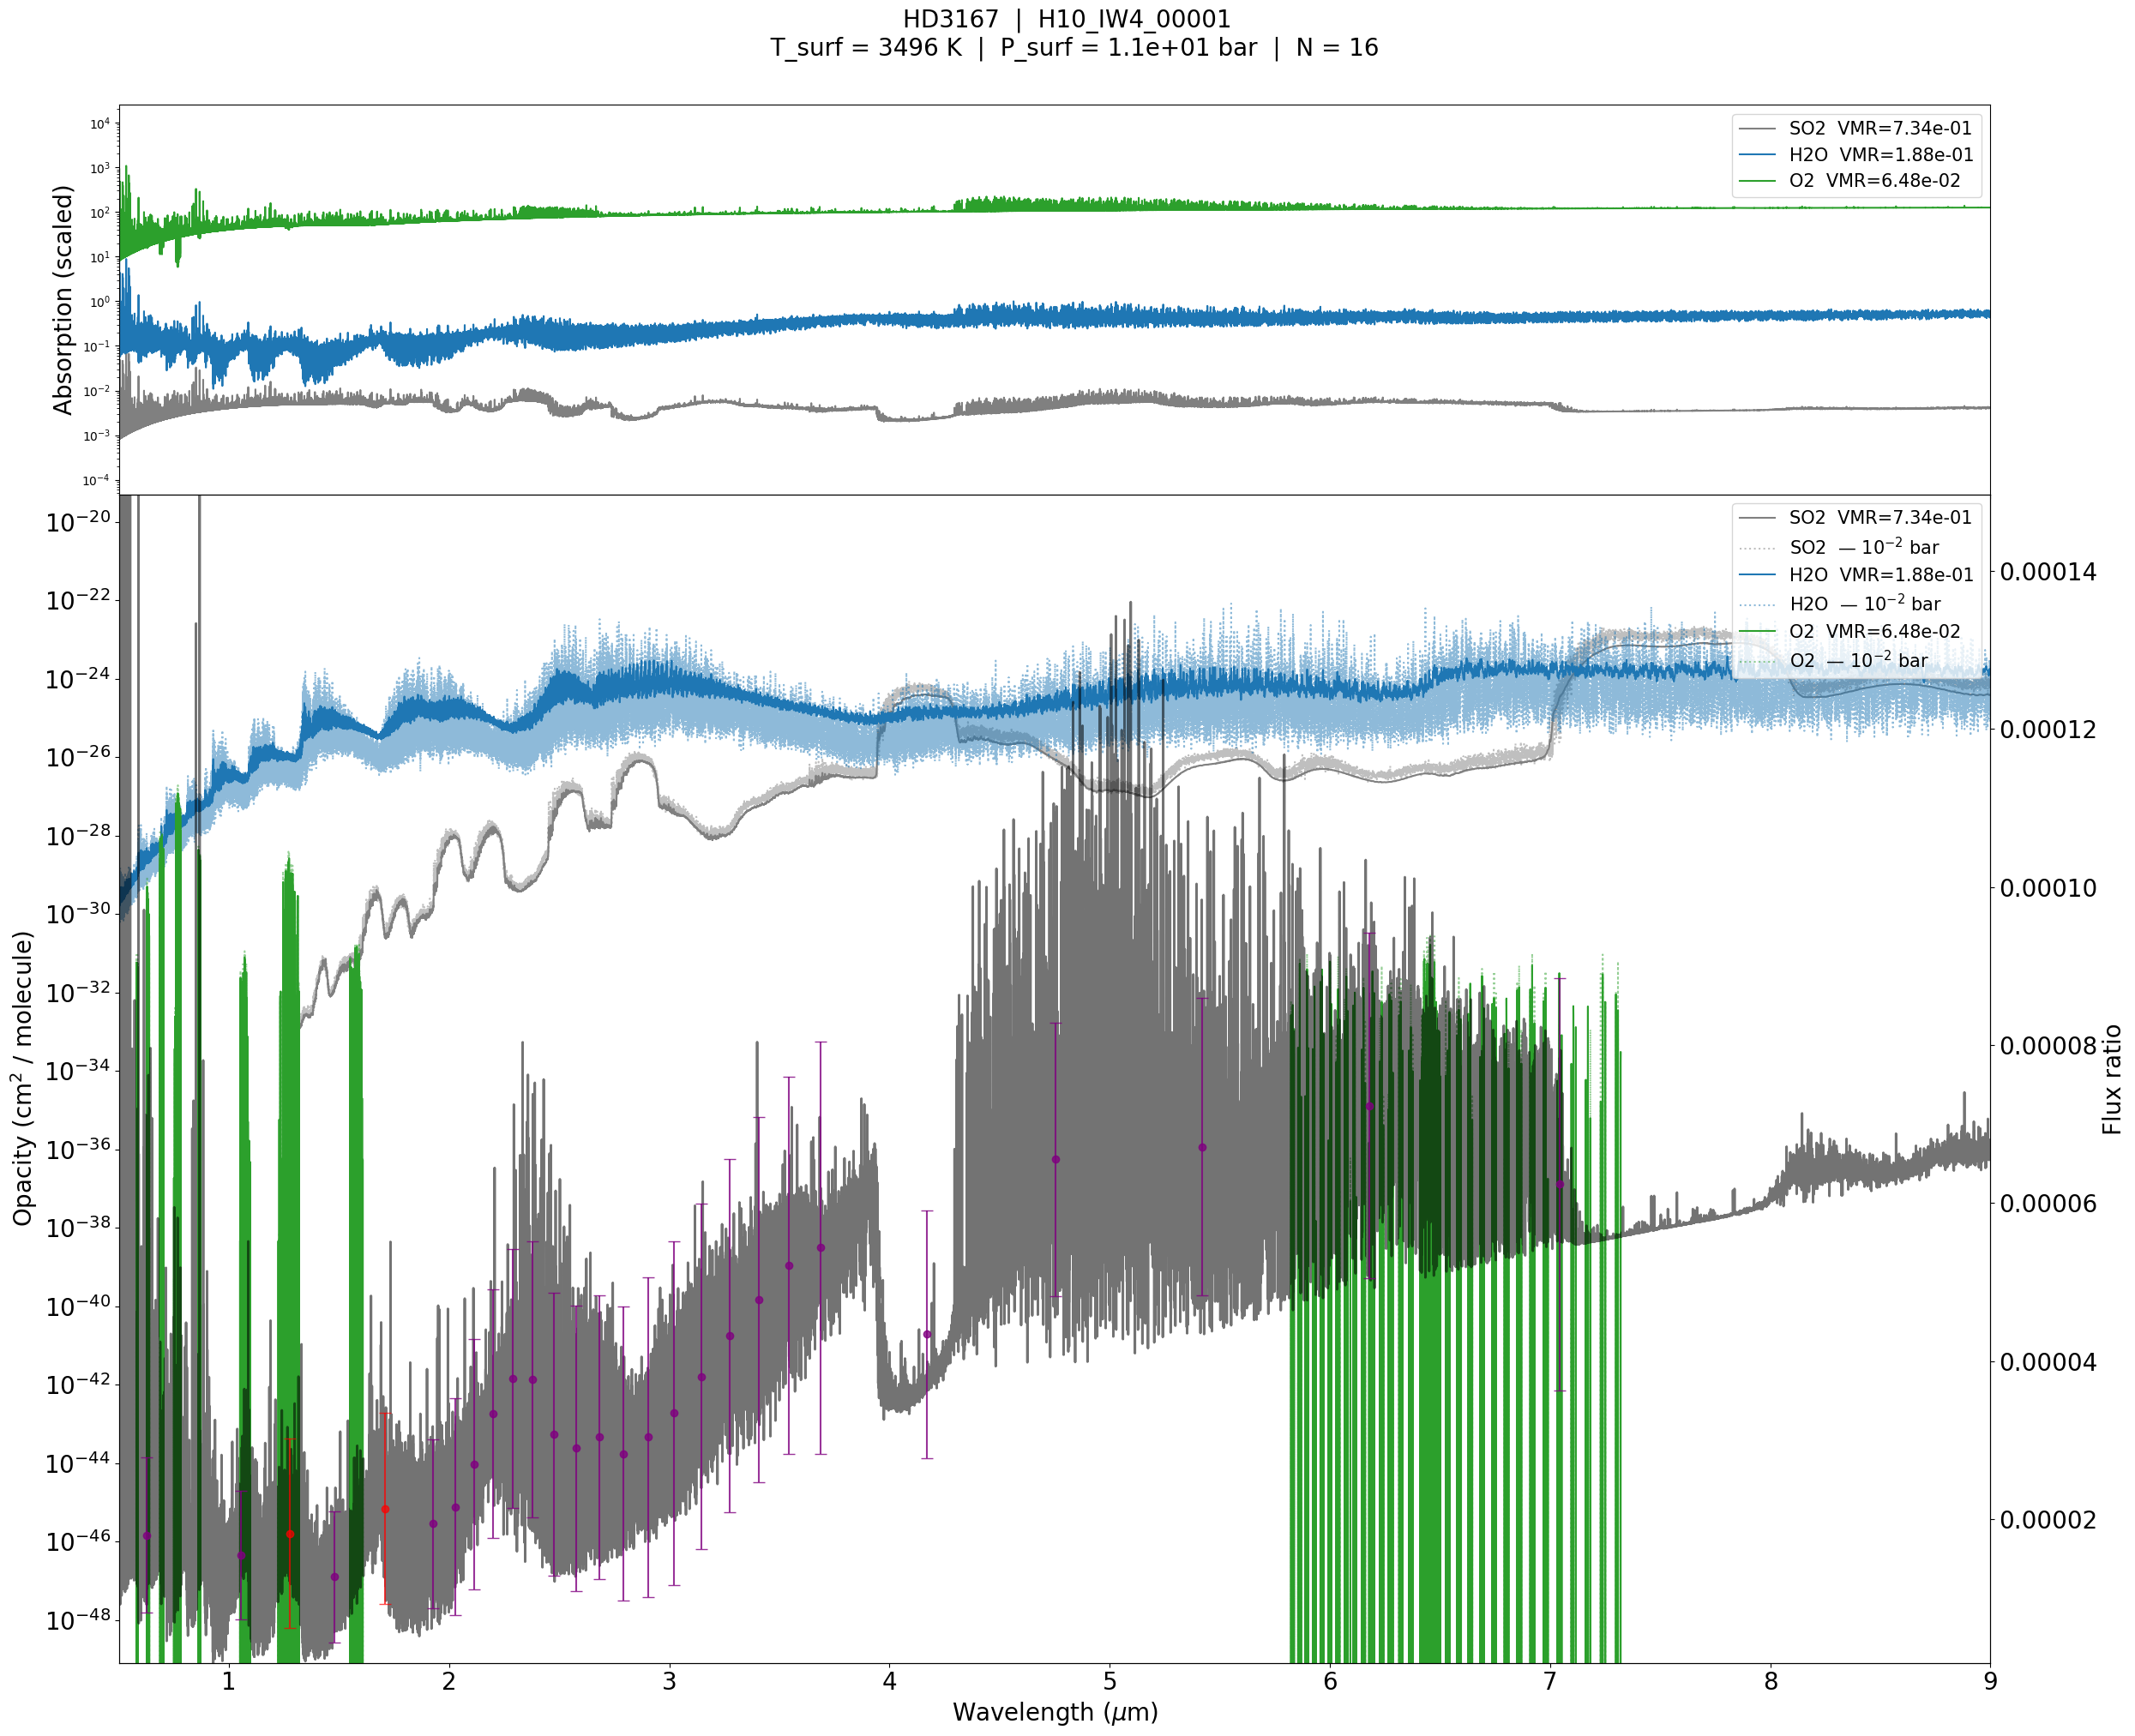

In [110]:
# ── Level-1 binning ───────────────────────────────────────────────────────────
new_points = [(wl[i], wb[i], wl[j], wb[j]) for i, j in bin_indices]

# ---- Read chemistry from runtime_helpfile ----
helpfile_path = f'PLANETS/{planet_name}/{sim_name}/runtime_helpfile.csv'
helpdata = pd.read_csv(helpfile_path, sep='\t')
last_row = helpdata.iloc[-1]

mol_vmrs = {}
for mol in mol_to_xsec:
    col = f'{mol}_vmr'
    if col in helpdata.columns:
        val = float(last_row[col])
        if val > 0:
            mol_vmrs[mol] = val

top2 = []
cumulative_vmr = 0.0
for mol, v in sorted(mol_vmrs.items(), key=lambda x: x[1], reverse=True):
    top2.append((mol, v))
    cumulative_vmr += v
    if len(top2) >= 3 or cumulative_vmr >= 0.999:
        break

# Indices of Ariel channels consumed by binning
used_indices = {idx for pair in bin_indices for idx in pair}
remaining    = np.array([i not in used_indices for i in range(len(wl))])

if binning:
    res1    = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, planet_name, *new_points)
    pts_wl  = [out[2] for out in res1]
    pts_val = [out[3] for out in res1]
    pts_err = [out[4] for out in res1]

# ── Fused figure ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(25, 20))
gs  = fig.add_gridspec(2, 1, height_ratios=[1, 3], hspace=0)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)
ax_bot_r = ax_bot.twinx()

# ── Top panel: stacked absorption contributions ───────────────────────────────
# Each curve is normalised to its own max, then shifted by 2 decades in log space
# so all features are visible regardless of absolute magnitude differences.
decades_gap = 2
for i, (mol, v) in enumerate(top2):
    contrib = locals()[f'{mol.lower()}_absorption']
    contrib_norm = contrib / contrib.max()          # peaks at 1, features preserved
    scale = 10 ** (i * decades_gap)                # shift up by i × decades_gap decades
    ax_top.plot(wavelength_um, contrib_norm * scale,
                color=MOL_COLORS[mol], ls='-', lw=1.5, label=f'{mol}  VMR={v:.2e}')

ax_top.set_yscale('log')
ax_top.set_xlim(0.5, 9)
#ax_top.set_yticks([10 ** (i * decades_gap) for i in range(len(top2))])
#ax_top.set_yticklabels([mol for mol, _ in top2], fontsize=18)
ax_top.set_ylabel(r'Absorption (scaled)', fontsize=20)
ax_top.legend(fontsize=15, loc='upper right')
ax_top.tick_params(axis='x', which='major', labelsize=20)
plt.setp(ax_top.get_xticklabels(), visible=False)

# ── Bottom panel: opacity cross-sections (left) + spectrum (right) ─────────────
for mol, v in top2:
    color    = MOL_COLORS[mol]
    xsec_obj = mol_to_xsec[mol]
    op_surf  = xsec_obj.opacity(float(surf_t), float(surf_p_pa))
    op_mid   = xsec_obj.opacity(float(mid_t),  float(target_p_pa))
    ax_bot.plot(wavelength_um, op_surf, color=color, ls='-',  lw=1.5, label=f'{mol}  VMR={v:.2e}')
    ax_bot.plot(wavelength_um, op_mid,  color=color, ls=':', lw=1.5,
                label=f'{mol}  — $10^{{-2}}$ bar', alpha=0.5)

ax_bot_r.plot(wlgrid_t, fpfs_t, color='black', ls='-', lw=2, alpha=0.55, label='model', zorder=10)

if binning:
    ax_bot_r.errorbar(wl_ariel[remaining], flux_ariel[remaining], yerr=yerr[remaining],
                      fmt='o', color='red', capsize=5, alpha=0.7, zorder=11)
    ax_bot_r.errorbar(pts_wl, pts_val, yerr=pts_err,
                      fmt='o', color='purple', capsize=5, alpha=0.8, label='binned L1', zorder=11)
else:
    ax_bot_r.errorbar(wl_ariel, flux_ariel, yerr=yerr,
                      fmt='o', color='red', alpha=0.7, label='Ariel')

mask = (wlgrid_t < 9) & (wlgrid_t > 1)
ax_bot_r.set_ylim(fpfs_t[mask].min() * 0.9, fpfs_t[mask].max() * 1.1)
ax_bot_r.set_ylabel('Flux ratio', fontsize=20)
ax_bot_r.tick_params(axis='both', which='major', labelsize=20)

ax_bot.set_yscale('log')
ax_bot.set_xlabel(r'Wavelength ($\mu$m)', fontsize=20)
ax_bot.set_ylabel(r'Opacity (cm$^2$ / molecule)', fontsize=20)
ax_bot.legend(fontsize=15, loc='upper right')
ax_bot.set_yticks([1e-20,1e-22,1e-24,1e-26,1e-28,1e-30,1e-32,1e-34,1e-36,1e-38,1e-40,1e-42,1e-44,1e-46,1e-48])
ax_bot.tick_params(axis='both', which='major', labelsize=20)

fig.suptitle(f'{planet_name}  |  {sim_name}\n  T_surf = {surf_t:.0f} K  |  P_surf = {surf_p_pa/1e5:.1e} bar  |  N = {N}',
             fontsize=20, y=1.01)
plt.tight_layout()
plt.show()


In [111]:
# ── Build combined table: remaining Ariel channels + L1 binned points ─────────
# Each entry: (center_wl, bandwidth, flux_val, flux_err, label)
combined = []
for i in range(len(wl)):
    if i not in used_indices:
        combined.append((wl[i], wb[i], flux_ariel[i], yerr[i], f'Ariel [{i}]'))
for out in res1:
    combined.append((out[2], out[5], out[3], out[4], 'L1 bin'))
combined.sort(key=lambda x: x[0])

print(f"{'idx':>4}  {'wl (µm)':>10}  {'bw (µm)':>10}  source")
print("-" * 42)
for i, (w, b, v, e, lbl) in enumerate(combined):
    print(f"  {i:2d}    {w:10.4f}    {b:10.4f}   {lbl}")

 idx     wl (µm)     bw (µm)  source
------------------------------------------
   0        0.6250        0.3000   L1 bin
   1        1.0532        0.4128   L1 bin
   2        1.2749        0.1243   Ariel [4]
   3        1.4776        0.2881   L1 bin
   4        1.7085        0.1666   Ariel [7]
   5        1.9266        0.1974   L1 bin
   6        2.0294        0.0808   L1 bin
   7        2.1118        0.0840   L1 bin
   8        2.1975        0.0875   L1 bin
   9        2.2868        0.0910   L1 bin
  10        2.3796        0.0947   L1 bin
  11        2.4762        0.0986   L1 bin
  12        2.5768        0.1026   L1 bin
  13        2.6814        0.1067   L1 bin
  14        2.7903        0.1111   L1 bin
  15        2.9036        0.1156   L1 bin
  16        3.0215        0.1203   L1 bin
  17        3.1442        0.1251   L1 bin
  18        3.2718        0.1302   L1 bin
  19        3.4047        0.1355   L1 bin
  20        3.5429        0.1410   L1 bin
  21        3.6868        0.1467

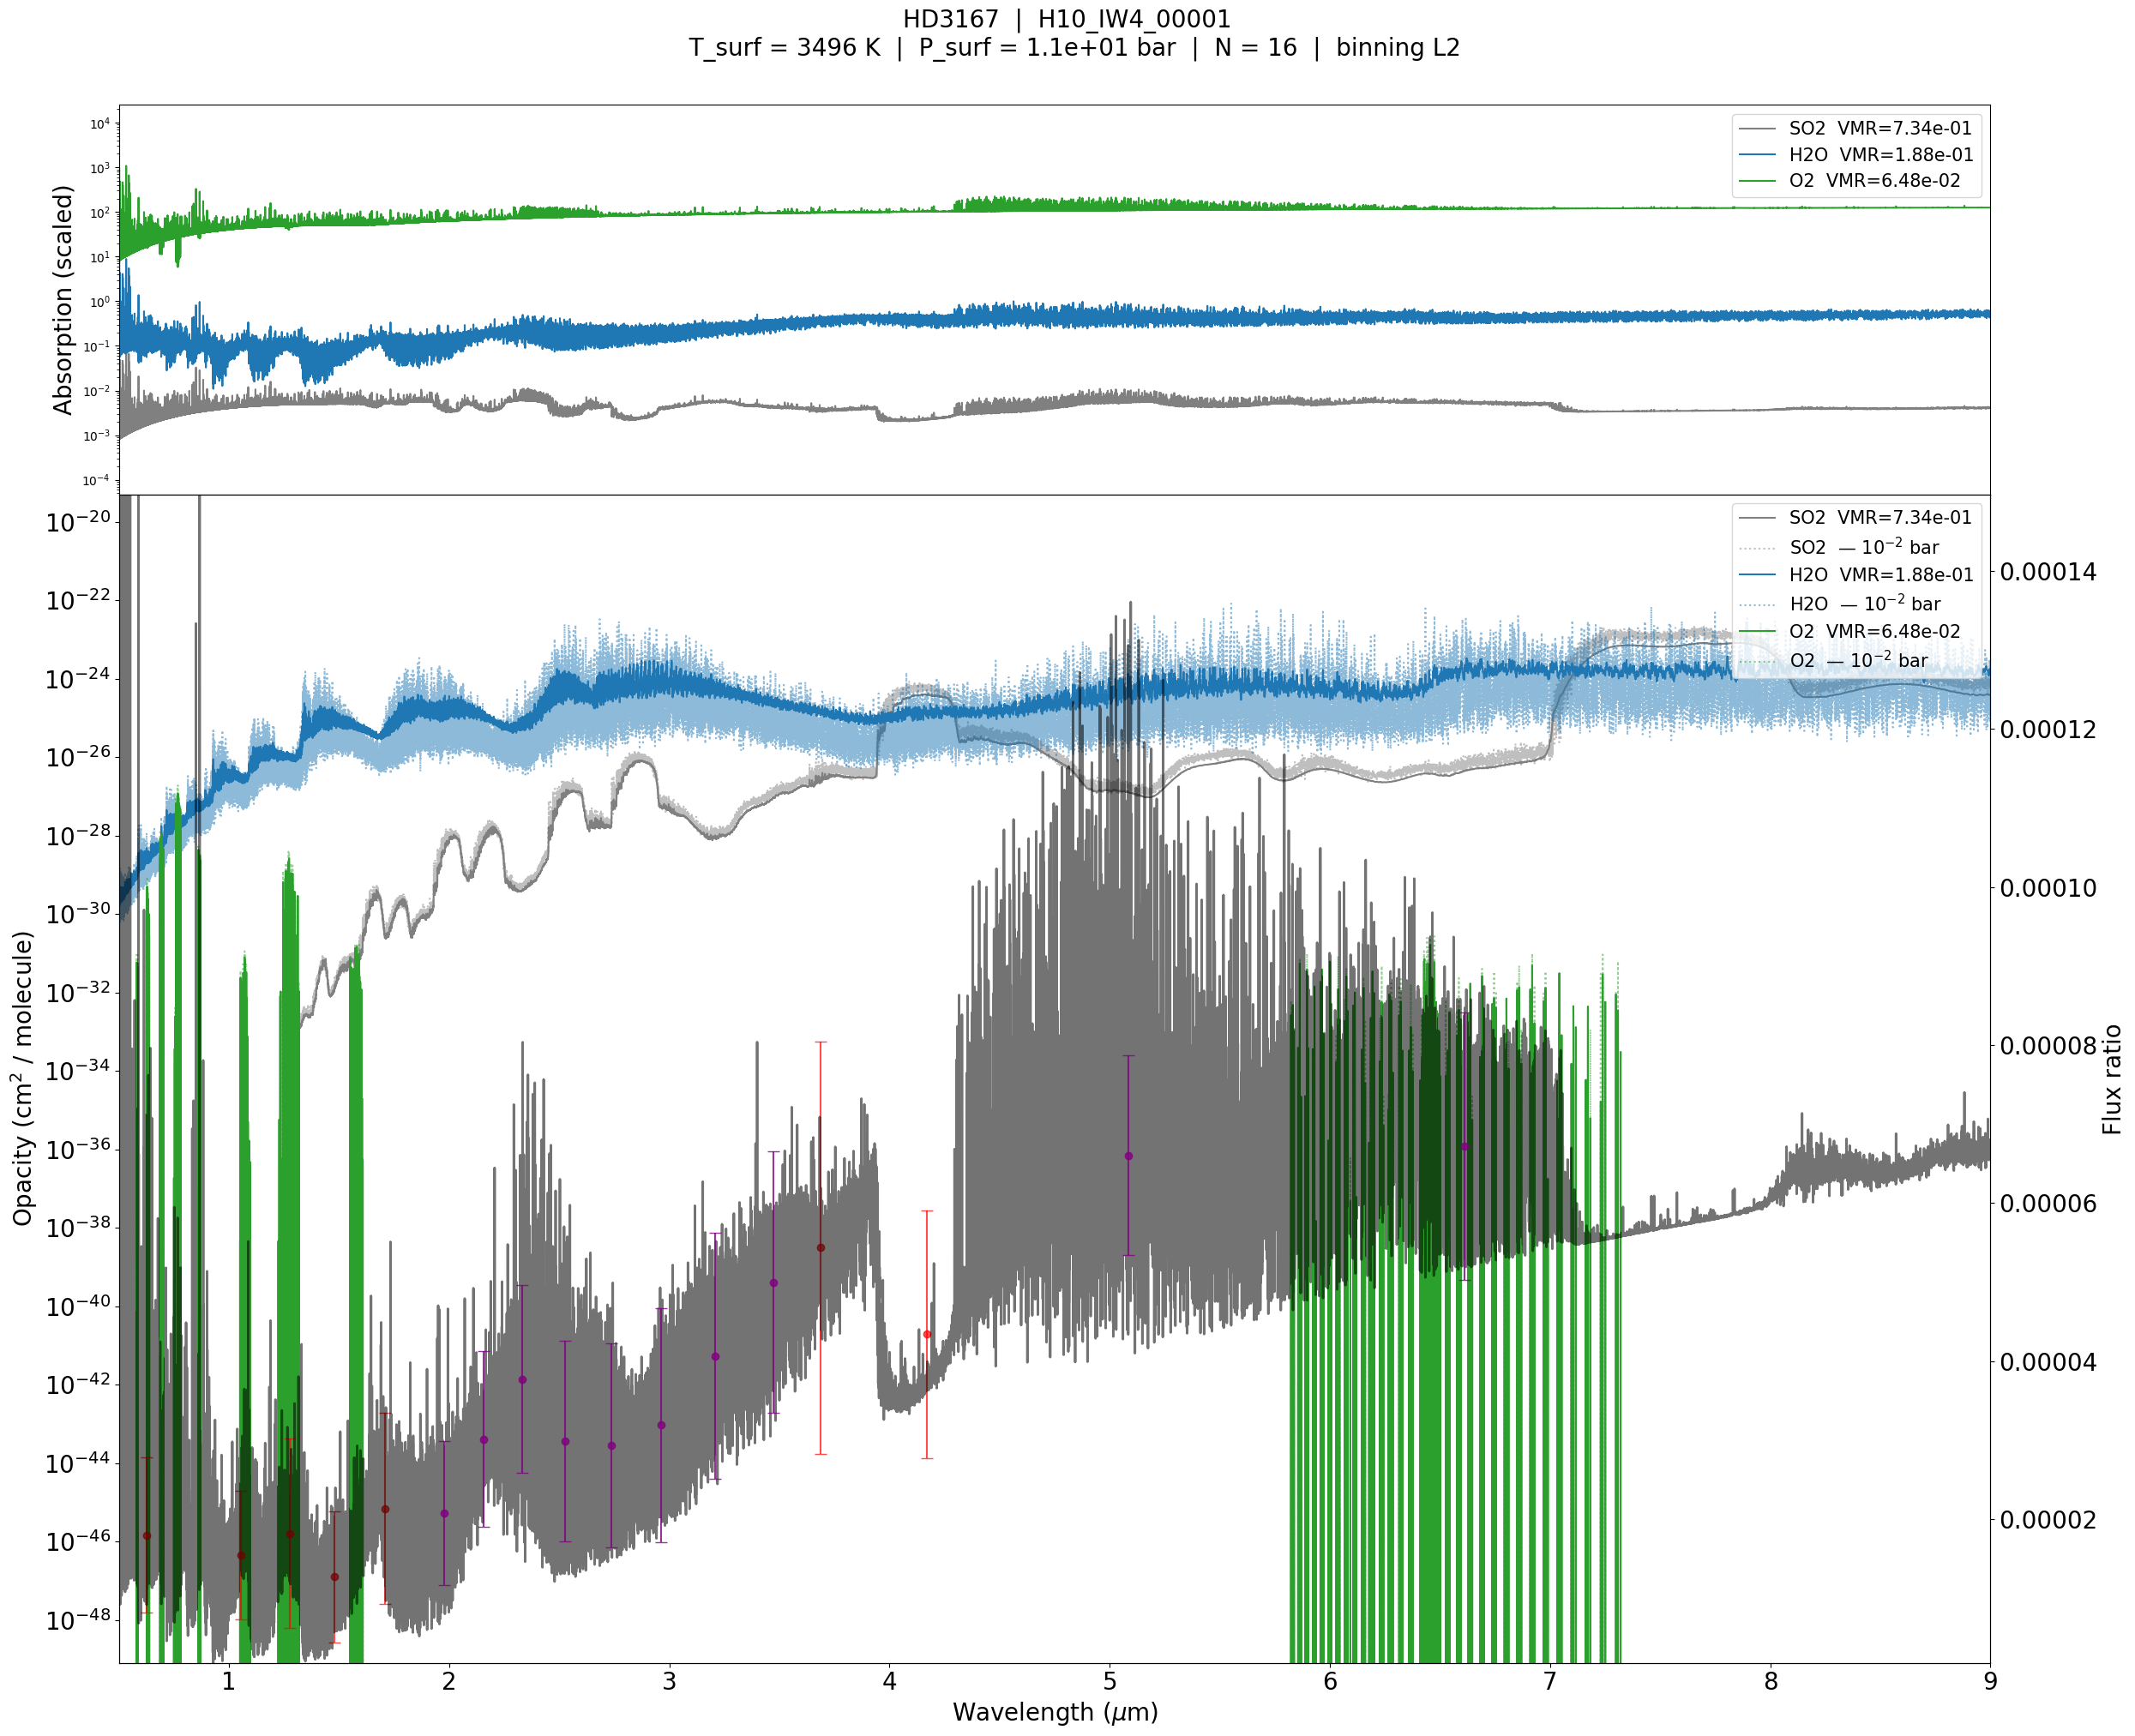

In [112]:
# ── Level-2 binning ───────────────────────────────────────────────────────────
# Edit bin_indices_l2, then run. First run prints the updated table so you can
# pick indices; re-run after editing to get the plot.
bin_indices_l2 = [(5,6),(7,8),(9,10),(11,12),(13,14),(15,16),(17,18),(19,20),(23,24),(25,26)]

# ── Run L2 binning ─────────────────────────────────────────────────────────────
new_points_l2 = [(combined[i][0], combined[i][1], combined[j][0], combined[j][1])
                 for i, j in bin_indices_l2]
res2 = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, planet_name, *new_points_l2)

# ── Plot ───────────────────────────────────────────────────────────────────────
used_l2      = {idx for pair in bin_indices_l2 for idx in pair}
remaining_l2 = [i not in used_l2 for i in range(len(combined))]

# ── Fused figure ──────────────────────────────────────────────────────────────
fig3 = plt.figure(figsize=(25, 20))
gs3  = fig3.add_gridspec(2, 1, height_ratios=[1, 3], hspace=0)

ax3_top = fig3.add_subplot(gs3[0])
ax3_bot = fig3.add_subplot(gs3[1], sharex=ax3_top)
ax3b    = ax3_bot.twinx()

# ── Top panel: stacked absorption contributions ───────────────────────────────
decades_gap = 2
for i, (mol, v) in enumerate(top2):
    contrib = locals()[f'{mol.lower()}_absorption']
    contrib_norm = contrib / contrib.max()
    scale = 10 ** (i * decades_gap)
    ax3_top.plot(wavelength_um, contrib_norm * scale,
                color=MOL_COLORS[mol], ls='-', lw=1.5, label=f'{mol}  VMR={v:.2e}')

ax3_top.set_yscale('log')
ax3_top.set_xlim(0.5, 9)
ax3_top.set_ylabel(r'Absorption (scaled)', fontsize=20)
ax3_top.legend(fontsize=15, loc='upper right')
ax3_top.tick_params(axis='x', which='major', labelsize=20)
plt.setp(ax3_top.get_xticklabels(), visible=False)

# ── Bottom panel: opacity cross-sections (left) + spectrum (right) ────────────
for mol, v in top2:
    color    = MOL_COLORS[mol]
    xsec_obj = mol_to_xsec[mol]
    op_surf  = xsec_obj.opacity(float(surf_t), float(surf_p_pa))
    op_mid   = xsec_obj.opacity(float(mid_t),  float(target_p_pa))
    ax3_bot.plot(wavelength_um, op_surf, color=color, ls='-', lw=1.5, label=f'{mol}  VMR={v:.2e}')
    ax3_bot.plot(wavelength_um, op_mid,  color=color, ls=':', lw=1.5,
                label=f'{mol}  — $10^{{-2}}$ bar', alpha=0.5)

ax3b.plot(wlgrid_t, fpfs_t, color='black', ls='-', lw=2, alpha=0.55, label='model', zorder=10)

rem_wl  = [combined[i][0] for i, keep in enumerate(remaining_l2) if keep]
rem_val = [combined[i][2] for i, keep in enumerate(remaining_l2) if keep]
rem_err = [combined[i][3] for i, keep in enumerate(remaining_l2) if keep]
ax3b.errorbar(rem_wl, rem_val, yerr=rem_err,
              fmt='o', color='red', capsize=5, alpha=0.7, label='unchanged')

pts_wl  = [out[2] for out in res2]
pts_val = [out[3] for out in res2]
pts_err = [out[4] for out in res2]
ax3b.errorbar(pts_wl, pts_val, yerr=pts_err,
              fmt='o', color='purple', capsize=5, alpha=0.8, label='binned L2', zorder=11)

mask = (wlgrid_t < 9) & (wlgrid_t > 1)
ax3b.set_ylim(fpfs_t[mask].min() * 0.9, fpfs_t[mask].max() * 1.1)
ax3b.set_ylabel('Flux ratio', fontsize=20)
ax3b.tick_params(axis='both', which='major', labelsize=20)

ax3_bot.set_yscale('log')
ax3_bot.set_xlabel(r'Wavelength ($\mu$m)', fontsize=20)
ax3_bot.set_ylabel(r'Opacity (cm$^2$ / molecule)', fontsize=20)
ax3_bot.legend(fontsize=15, loc='upper right')
ax3_bot.set_yticks([1e-20,1e-22,1e-24,1e-26,1e-28,1e-30,1e-32,1e-34,1e-36,1e-38,1e-40,1e-42,1e-44,1e-46,1e-48])
ax3_bot.tick_params(axis='both', which='major', labelsize=20)

fig3.suptitle(f'{planet_name}  |  {sim_name}\n  T_surf = {surf_t:.0f} K  |  P_surf = {surf_p_pa/1e5:.1e} bar  |  N = {N}  |  binning L2',
              fontsize=20, y=1.01)
plt.tight_layout()
plt.show()


In [113]:
# ── Build combined table: remaining L2 points + L2 binned results ─────────────
# Each entry: (center_wl, bandwidth, flux_val, flux_err, label)
combined_l2 = []
for i, keep in enumerate(remaining_l2):
    if keep:
        combined_l2.append((*combined[i],))
for out in res2:
    combined_l2.append((out[2], out[5], out[3], out[4], 'L2 bin'))
combined_l2.sort(key=lambda x: x[0])

print(f"{'idx':>4}  {'wl (µm)':>10}  {'bw (µm)':>10}  source")
print("-" * 42)
for i, (w, b, v, e, lbl) in enumerate(combined_l2):
    print(f"  {i:2d}    {w:10.4f}    {b:10.4f}   {lbl}")


 idx     wl (µm)     bw (µm)  source
------------------------------------------
   0        0.6250        0.3000   L1 bin
   1        1.0532        0.4128   L1 bin
   2        1.2749        0.1243   Ariel [4]
   3        1.4776        0.2881   L1 bin
   4        1.7085        0.1666   Ariel [7]
   5        1.9780        0.2419   L2 bin
   6        2.1547        0.1715   L2 bin
   7        2.3332        0.1857   L2 bin
   8        2.5265        0.2011   L2 bin
   9        2.7358        0.2178   L2 bin
  10        2.9625        0.2358   L2 bin
  11        3.2080        0.2553   L2 bin
  12        3.4738        0.2765   L2 bin
  13        3.6868        0.1467   L1 bin
  14        4.1688        0.5466   L1 bin
  15        5.0861        1.3330   L2 bin
  16        6.6117        1.7328   L2 bin


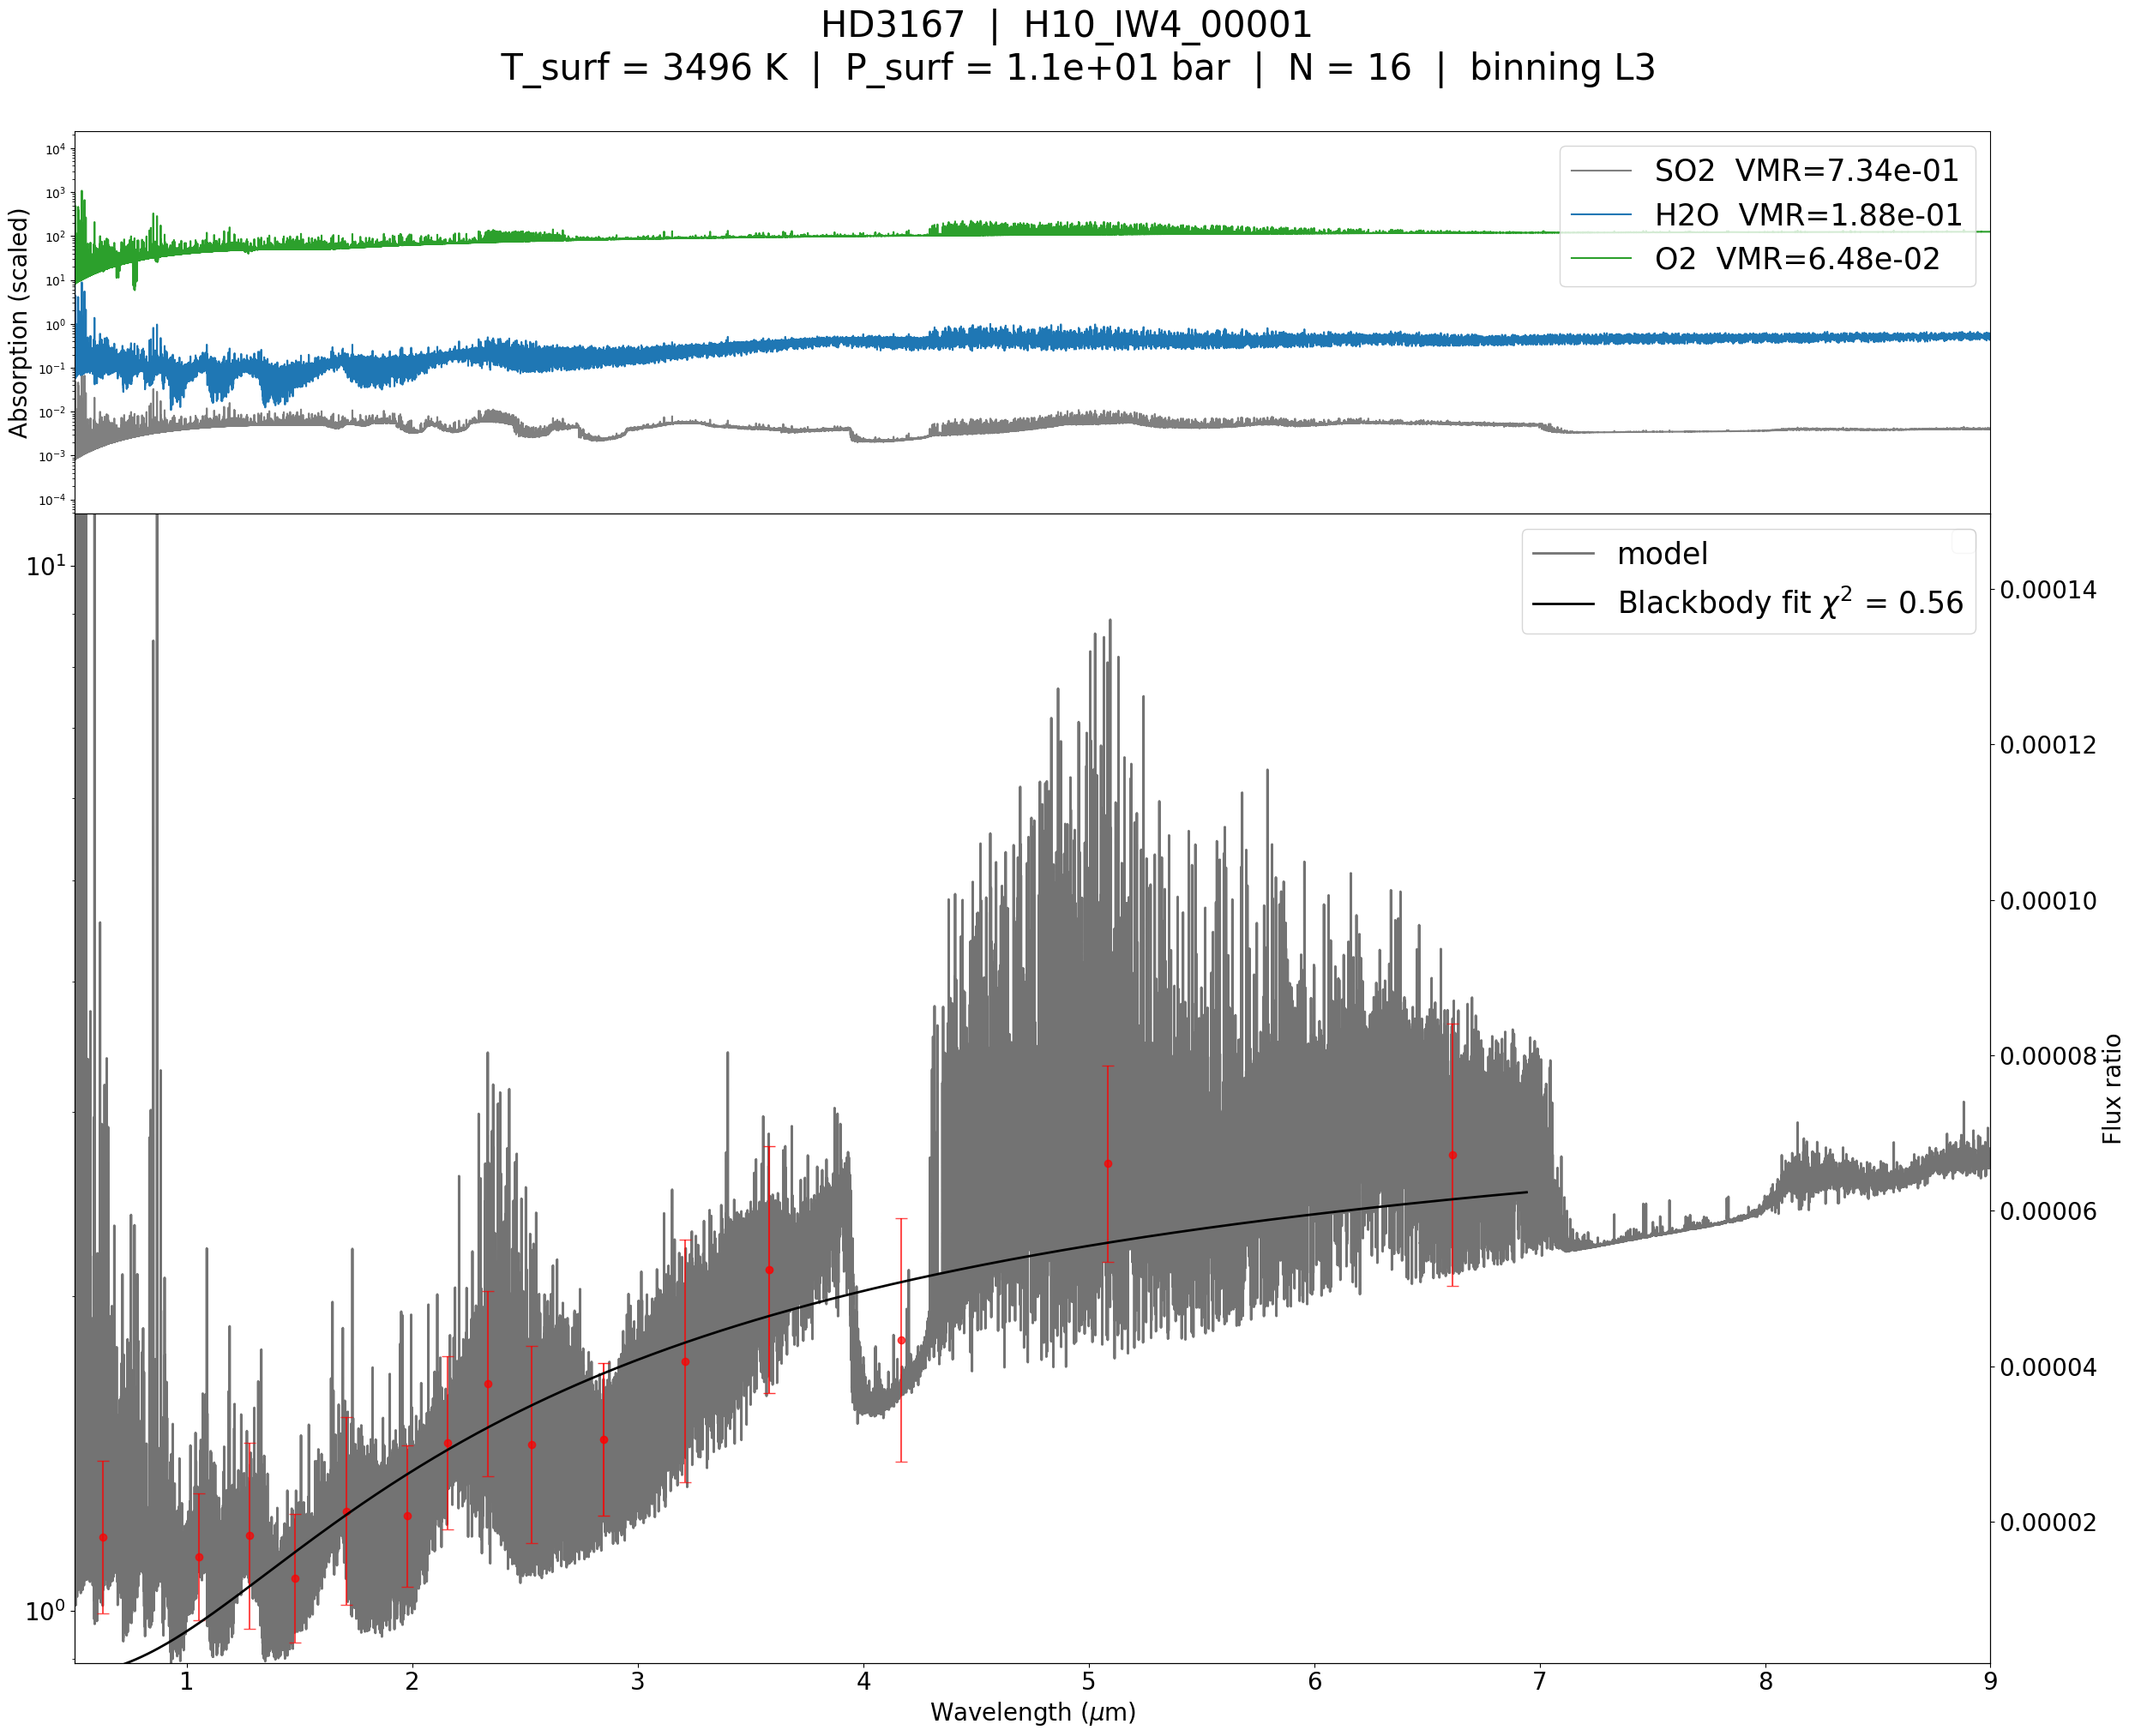

In [114]:
# ── Level-3 binning ───────────────────────────────────────────────────────────
# Edit bin_indices_l3, then run. First run prints the updated table so you can
# pick indices; re-run after editing to get the plot.
bin_indices_l3 = [(9,10),(12,13)]

# ── Run L3 binning ─────────────────────────────────────────────────────────────
new_points_l3 = [(combined_l2[i][0], combined_l2[i][1], combined_l2[j][0], combined_l2[j][1])
                 for i, j in bin_indices_l3]
res3 = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, planet_name, *new_points_l3)

# ── Plot ───────────────────────────────────────────────────────────────────────
used_l3      = {idx for pair in bin_indices_l3 for idx in pair}
remaining_l3 = [i not in used_l3 for i in range(len(combined_l2))]

# ── Fused figure ──────────────────────────────────────────────────────────────
fig4 = plt.figure(figsize=(25, 20))
gs4  = fig4.add_gridspec(2, 1, height_ratios=[1, 3], hspace=0)

ax4_top = fig4.add_subplot(gs4[0])
ax4_bot = fig4.add_subplot(gs4[1], sharex=ax4_top)
ax4b    = ax4_bot.twinx()

# ── Top panel: stacked absorption contributions ───────────────────────────────
decades_gap = 2
for i, (mol, v) in enumerate(top2):
    contrib = locals()[f'{mol.lower()}_absorption']
    contrib_norm = contrib / contrib.max()
    scale = 10 ** (i * decades_gap)
    ax4_top.plot(wavelength_um, contrib_norm * scale,
                color=MOL_COLORS[mol], ls='-', lw=1.5, label=f'{mol}  VMR={v:.2e}')

ax4_top.set_yscale('log')
ax4_top.set_xlim(0.5, 9)
ax4_top.set_ylabel(r'Absorption (scaled)', fontsize=20)
ax4_top.legend(fontsize=25, loc='upper right')
ax4_top.tick_params(axis='x', which='major', labelsize=20)
plt.setp(ax4_top.get_xticklabels(), visible=False)

# ── Bottom panel: opacity cross-sections (left) + spectrum (right) ────────────
#for mol, v in top2:
    #color    = MOL_COLORS[mol]
    #xsec_obj = mol_to_xsec[mol]
    #op_surf  = xsec_obj.opacity(float(surf_t), float(surf_p_pa))
    #op_mid   = xsec_obj.opacity(float(mid_t),  float(target_p_pa))
    #ax4_bot.plot(wavelength_um, op_surf, color=color, ls='-', lw=1.5, label=f'{mol}  VMR={v:.2e}')
    #ax4_bot.plot(wavelength_um, op_mid,  color=color, ls=':', lw=1.5,
                #label=f'{mol}  — $10^{{-2}}$ bar', alpha=0.5)

ax4b.plot(wlgrid_t, fpfs_t, color='black', ls='-', lw=2, alpha=0.55, label='model', zorder=10)

rem_wl  = [combined_l2[i][0] for i, keep in enumerate(remaining_l3) if keep]
rem_val = [combined_l2[i][2] for i, keep in enumerate(remaining_l3) if keep]
rem_err = [combined_l2[i][3] for i, keep in enumerate(remaining_l3) if keep]
ax4b.errorbar(rem_wl, rem_val, yerr=rem_err,
              fmt='o', color='red', capsize=5, alpha=0.7,zorder=11)

pts_wl  = [out[2] for out in res3]
pts_val = [out[3] for out in res3]
pts_err = [out[4] for out in res3]
ax4b.errorbar(pts_wl, pts_val, yerr=pts_err,
              fmt='o', color='red', capsize=5, alpha=0.8, zorder=11)

#create one combined table for remaining L3 points + L3 binned results

mask = (wlgrid_t < 9) & (wlgrid_t > 1)
ax4b.set_ylim(fpfs_t[mask].min() * 0.9, fpfs_t[mask].max() * 1.1)
ax4b.set_ylabel('Flux ratio', fontsize=20)
ax4b.tick_params(axis='both', which='major', labelsize=20)

# ── Blackbody fit to final binned spectrum ───────────────────────────────────
from scipy.optimize import curve_fit as _curve_fit

def _planck(wl_um, T):
    h, c, k = 6.62607015e-34, 299792458.0, 1.380649e-23
    wl_m = wl_um * 1e-6
    return (2*h*c**2 / wl_m**5) / (np.exp(h*c / (wl_m*k*T)) - 1.0)

def _bb_fpfs(wl_um, T_p, k_rp):
    return k_rp * _planck(wl_um, T_p) / _planck(wl_um, star_temperature[idx])

wl_all  = np.array(rem_wl  + pts_wl)
val_all = np.array(rem_val + pts_val)
err_all = np.array(rem_err + pts_err)
sort_i  = np.argsort(wl_all)
wl_all, val_all, err_all = wl_all[sort_i], val_all[sort_i], err_all[sort_i]

rp_rs_sq_0 = (planet_radius[idx] * astropy.constants.R_earth.value /
              (star_radius[idx]   * astropy.constants.R_sun.value)) ** 2
popt_bb, _ = _curve_fit(_bb_fpfs, wl_all, val_all,
                         p0=[1500.0, rp_rs_sq_0], sigma=err_all,
                         bounds=([200, 0.3*rp_rs_sq_0], [6000, 3.0*rp_rs_sq_0]))
T_bb_fit, k_bb_fit = popt_bb
wl_fine_bb = np.linspace(wl_all.min() * 0.95, wl_all.max() * 1.05, 500)

residuals_bb = (val_all - _bb_fpfs(wl_all, T_bb_fit, k_bb_fit)) / err_all
chi2_bb      = np.sum(residuals_bb**2)
chi2_red_bb  = chi2_bb / (len(val_all) - 2)
#print(f'BB fit:  T_p = {T_bb_fit:.1f} K   χ² = {chi2_bb:.2f}   χ²_red = {chi2_red_bb:.2f}')

ax4b.plot(wl_fine_bb, _bb_fpfs(wl_fine_bb, T_bb_fit, k_bb_fit),
          color='black', lw=2, ls='-', label=rf'Blackbody fit $\chi^2$ = {chi2_red_bb:.2f}', zorder=12)


ax4_bot.set_yscale('log')
ax4_bot.set_xlabel(r'Wavelength ($\mu$m)', fontsize=20)
#ax4_bot.set_ylabel(r'Opacity (cm$^2$ / molecule)', fontsize=20)
ax4_bot.legend(fontsize=25, loc='upper right')
ax4b.legend(fontsize=25, loc='upper right')
#ax4_bot.set_yticks([1e-20,1e-22,1e-24,1e-26,1e-28,1e-30,1e-32,1e-34,1e-36,1e-38,1e-40,1e-42,1e-44,1e-46,1e-48])
ax4_bot.tick_params(axis='both', which='major', labelsize=20)

fig4.suptitle(f'{planet_name}  |  {sim_name}\n  T_surf = {surf_t:.0f} K  |  P_surf = {surf_p_pa/1e5:.1e} bar  |  N = {N}  |  binning L3',
              fontsize=30, y=1.01)
plt.tight_layout()
plt.show()


In [115]:
# save full binned spectrum (unchanged L3 points + newly binned L3 points)
full_wl  = list(rem_wl)  + [out[2] for out in res3]
full_val = list(rem_val) + [out[3] for out in res3]
full_err = list(rem_err) + [out[4] for out in res3]
full_bw  = [combined_l2[i][1] for i, keep in enumerate(remaining_l3) if keep] + [out[5] for out in res3]

# sort by wavelength
order    = sorted(range(len(full_wl)), key=lambda i: full_wl[i])
full_wl  = [full_wl[i]  for i in order]
full_val = [full_val[i] for i in order]
full_err = [full_err[i] for i in order]
full_bw  = [full_bw[i]  for i in order]

np.savetxt(
    f'PLANETS/{planet_name}/{sim_name}_binned_spectrum.dat',
    np.column_stack([full_wl,full_val, full_err, full_bw]),
    header='',
    comments='',
)

In [99]:
indices_data = pd.DataFrame({
    'Planet': planet_name,
    'Simulation': sim_name,
    'Observations': N,
    'Integration time (hr)': N * planet_transit[planet_names.index(planet_name)],  # assuming 1 hr per observation; adjust if different
    'Indices_l1': [bin_indices],
    'Indices_l2': [bin_indices_l2],
    'Indices_l3': [bin_indices_l3],
    'Feature': 'SO2'
})
indices_data.to_csv(f'PLANETS/{planet_name}/{sim_name}_binning_indices.csv', index=False)